In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("Machine Learning /Mall_Customers.csv")
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [56]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [57]:
#basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [58]:
#Checking the size of our data
df.shape

(200, 5)

In [59]:
# Describing the data set
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [3]:
print(df.duplicated().sum())

0


In [61]:
# Performing the necessary data pre-processing technique (missing values, normalization,etc)
# Checking for missing values
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [62]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [4]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})

In [5]:
# Preprocess the data
df = df.drop('CustomerID', axis=1)
df = df.astype('float')

In [6]:
df.dtypes

Gender                    float64
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

In [66]:
df.isna().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

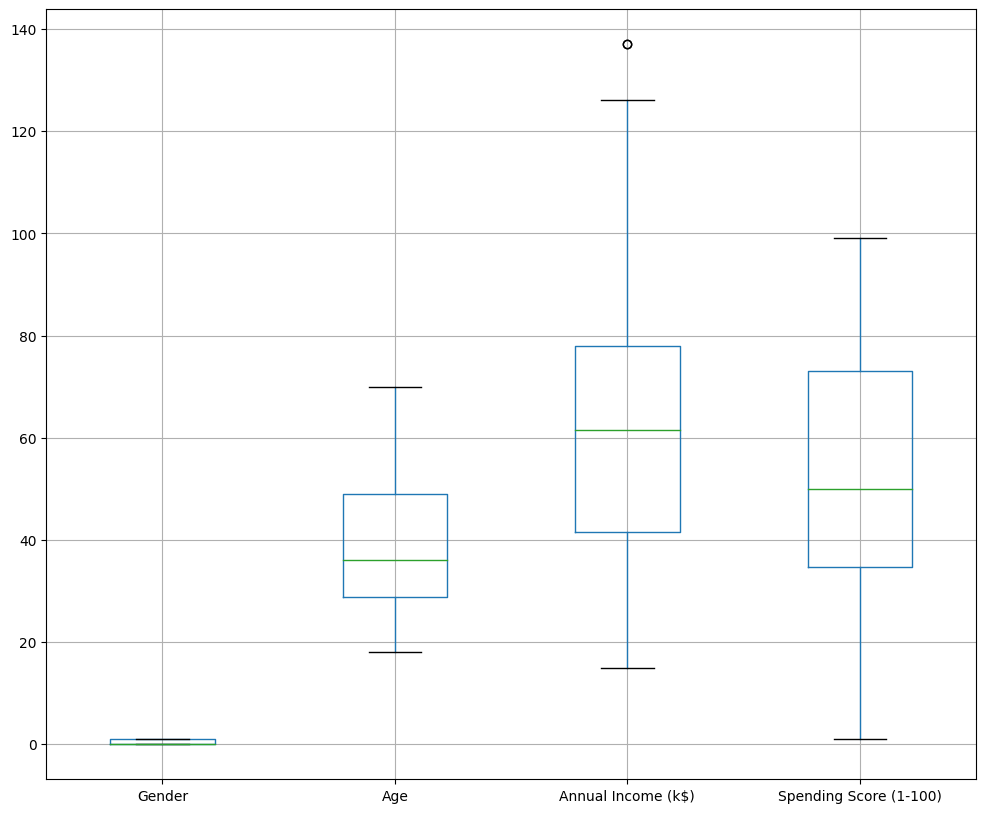

In [67]:
df.boxplot(figsize=(12,10))
plt.show()

In [7]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
#print(((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))))
print(((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum())

Gender                    0
Age                       0
Annual Income (k$)        2
Spending Score (1-100)    0
dtype: int64


Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


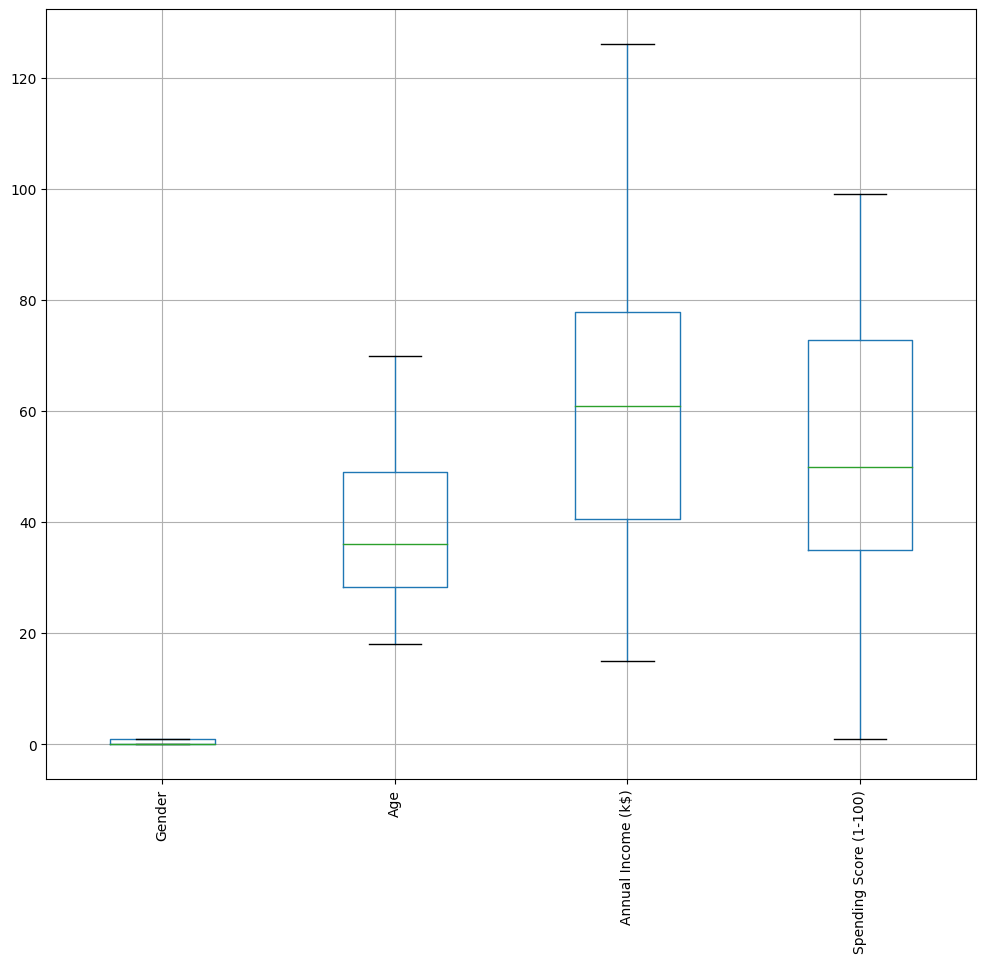

In [8]:
df1 = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(((df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))).sum())
df1.boxplot(figsize=(12,10))
plt.tick_params(axis='x', labelrotation = 90)
plt.show()

In [70]:
print(df1.isna().sum())

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [71]:
print(df1)

     Gender   Age  Annual Income (k$)  Spending Score (1-100)
0       1.0  19.0                15.0                    39.0
1       1.0  21.0                15.0                    81.0
2       0.0  20.0                16.0                     6.0
3       0.0  23.0                16.0                    77.0
4       0.0  31.0                17.0                    40.0
..      ...   ...                 ...                     ...
193     0.0  38.0               113.0                    91.0
194     0.0  47.0               120.0                    16.0
195     0.0  35.0               120.0                    79.0
196     0.0  45.0               126.0                    28.0
197     1.0  32.0               126.0                    74.0

[198 rows x 4 columns]


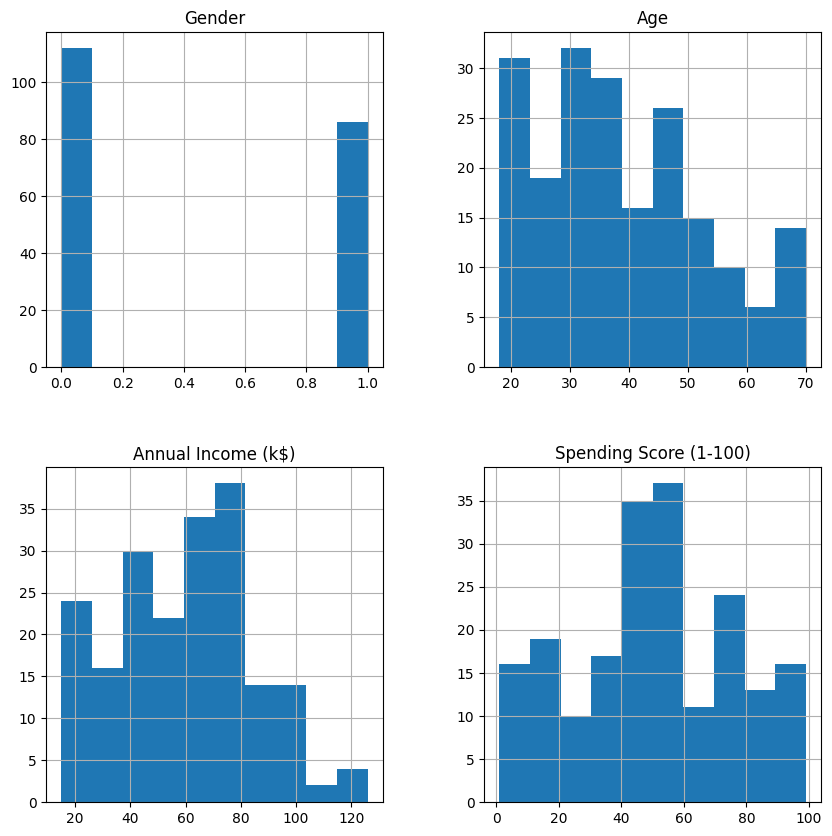

In [72]:
df1.hist(figsize=(10,10))
plt.show()

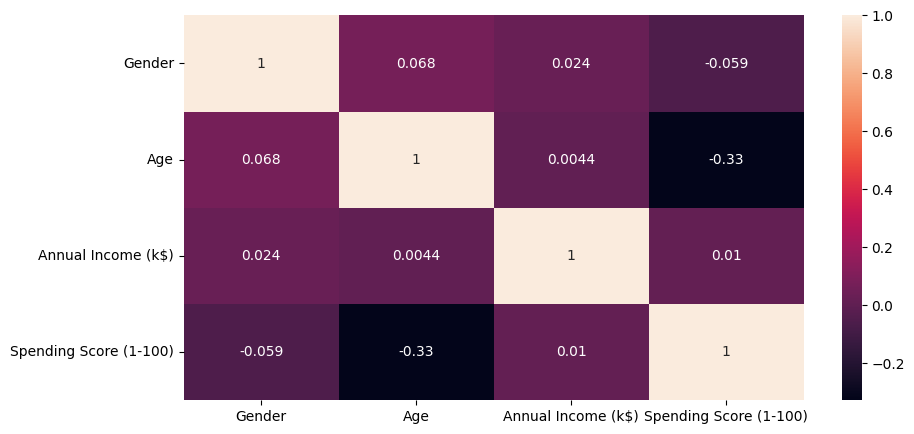

In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(df1.corr(),annot=True)
plt.show()

In [10]:
# Normalizing the data using Min-Max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df1)
X_scaled = pd.DataFrame(X_scaled, columns=df1.columns)
print(X_scaled)

     Gender       Age  Annual Income (k$)  Spending Score (1-100)
0       1.0  0.019231            0.000000                0.387755
1       1.0  0.057692            0.000000                0.816327
2       0.0  0.038462            0.009009                0.051020
3       0.0  0.096154            0.009009                0.775510
4       0.0  0.250000            0.018018                0.397959
..      ...       ...                 ...                     ...
193     0.0  0.384615            0.882883                0.918367
194     0.0  0.557692            0.945946                0.153061
195     0.0  0.326923            0.945946                0.795918
196     0.0  0.519231            1.000000                0.275510
197     1.0  0.269231            1.000000                0.744898

[198 rows x 4 columns]


In [11]:
from sklearn.feature_selection import SelectKBest, chi2
# Define the target variable as the segment label column
y = df['Age']

# Define the feature variables as the rest of the columns
X = df.drop('Age', axis=1)
# Create a SelectKBest object with chi-squared as the scoring function and k=3 as the number of features to select
selector = SelectKBest(chi2, k=3)

# Fit the selector to the data and transform the features
X_new = selector.fit_transform(X, y)

# Get the names of the selected features
selected_features = X.columns[selector.get_support()]

# Print the selected features
print('The selected features are:', selected_features)

The selected features are: Index(['Gender', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


In [12]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
# Separate the features and target variable
X = X_scaled.drop(['Age'], axis=1)
y = X_scaled['Age']

In [13]:
# Apply feature selection
selector = SelectKBest(f_classif, k=3)
X_new = selector.fit_transform(X, y)

# Print the selected features
print(X.columns[selector.get_support()])

Index(['Gender', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


This will select the top 3 features based on their ANOVA F-value. 

In [14]:
corr = X_scaled.corr()
print(corr['Age'])

Gender                    0.067835
Age                       1.000000
Annual Income (k$)        0.004406
Spending Score (1-100)   -0.329421
Name: Age, dtype: float64


# KMeans  clustering 

In [15]:
from sklearn.cluster import KMeans
#Creating values for the elbow
X = df.loc[:,["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
inertia = []
k = range(1,20)
for i in k:
    means_k = KMeans(n_clusters=i, random_state=0)
    means_k.fit(X)
    inertia.append(means_k.inertia_)
    

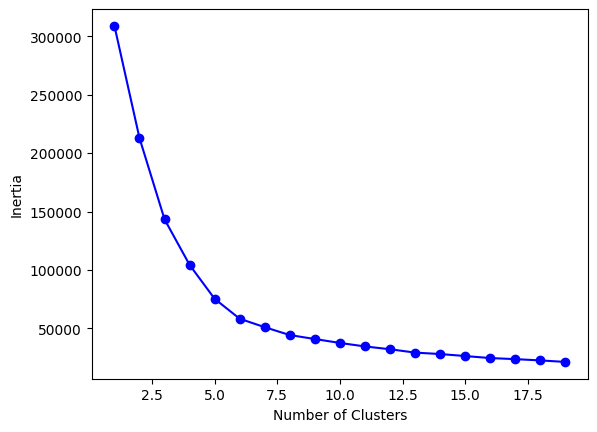

In [16]:
#Plotting the elbow
plt.plot(k , inertia , 'bo-')
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

The elbow method is used to determine the optimal number of clusters in k-means clustering. The elbow method plots the value of the cost function produced by different values of k and one should choose a number of clusters so that adding another cluster doesn't give much better modeling of the data. In this problem, we are using the inertia as cost function in order to identify the sum of squared distances of samples to the nearest cluster centre.

Looking at this particular example, if we imagine the line in the graphic is an arm, the elbow can be found, approximately, where the number of clusters is equal to 5. Therefore we are selecting 5 as the number of clusters to divide our data in.

In [17]:
#Training kmeans with 5 clusters
means_k = KMeans(n_clusters=5, random_state=0)
means_k.fit(X)
labels = means_k.labels_
centroids = means_k.cluster_centers_

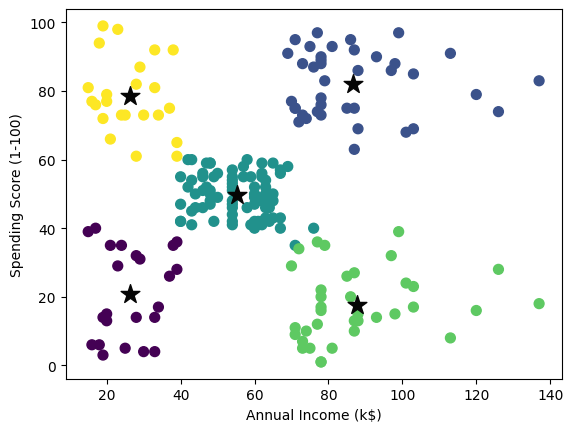

In [83]:
plt.scatter(X.iloc[:, 1], X.iloc[:, 2], c=labels, s=50)
plt.scatter(centroids[:, 1], centroids[:, 2], marker='*', s=200, c='#050505')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [84]:
import plotly as py
import plotly.graph_objs as go
#Create a 3d plot to view the data sepparation made by Kmeans
trace1 = go.Scatter3d(
    x= X['Spending Score (1-100)'],
    y= X['Annual Income (k$)'],
    z= X['Age'],
    mode='markers',
     marker=dict(
        color = labels, 
        size= 10,
        line=dict(
            color= labels,
        ),
        opacity = 0.9
     )
)
layout = go.Layout(
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Spending Score'),
            yaxis = dict(title  = 'Annual_income'),
            zaxis = dict(title  = 'Age')
        )
)
fig = go.Figure(data=trace1, layout=layout)
py.offline.iplot(fig)

In [18]:
from sklearn.metrics import silhouette_score
silhouette_score(X, labels)

0.44428597560893024

In [86]:
from sklearn.metrics import calinski_harabasz_score
calinski_harabasz_score(X, labels)

151.04386000160667

In [87]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(X, labels)

0.8218781633199781

# Hierarchical clustering

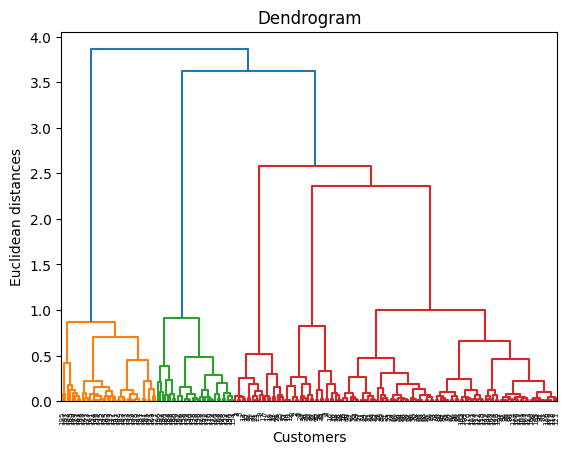

In [88]:
from scipy.cluster import hierarchy as sch
#plt.figure(1, figsize = (16 ,8))
X = X_scaled.iloc[:, [2, 3]].values
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()



In [19]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)
print(y_hc)



[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 0 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 1 2 1 2 1 2 0 2 1 2 1 2 1 2 1 2 0 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


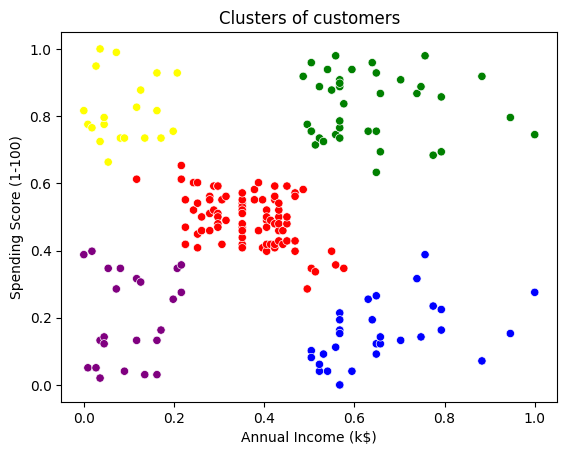

In [90]:
colors = ['red', 'green', 'blue', 'yellow', 'purple']
sns.scatterplot(data=X_scaled, x='Annual Income (k$)', y='Spending Score (1-100)', hue=y_hc, palette=colors, legend=False)
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [91]:
import plotly as py
import plotly.graph_objs as go
#Create a 3d plot to view the data sepparation made by  Hierarchical clustering

trace1 = go.Scatter3d(
    x= X_scaled['Spending Score (1-100)'],
    y= X_scaled['Annual Income (k$)'],
    z= X_scaled['Age'],
    mode='markers',
     marker=dict(
        color = y_hc, 
        size= 10,
        line=dict(
            color= y_hc,
        ),
        opacity = 0.9
     )
)
layout = go.Layout(
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Spending Score'),
            yaxis = dict(title  = 'Annual_income'),
            zaxis = dict(title  = 'Age')
        )
)
fig = go.Figure(data=trace1, layout=layout)
py.offline.iplot(fig)

In [92]:
from sklearn.metrics import silhouette_score
silhouette_score(X, y_hc)

0.5616014780954574

In [93]:
from sklearn.metrics import calinski_harabasz_score
calinski_harabasz_score(X, y_hc)

264.9544303154954

In [94]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(X, y_hc)

0.571161299710109

# kmodes clustering

In [21]:
from kmodes.kmodes import KModes
# Building the model with 5 clusters
kmode = KModes(n_clusters=5, init = "random", n_init = 5, verbose=1)
y_kmo = kmode.fit_predict(df1)
y_kmo
predicted_labels = pd.DataFrame(y_kmo, columns=['predicted-label'])

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 11, cost: 535.0
Run 1, iteration: 2/100, moves: 0, cost: 535.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 66, cost: 532.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 15, cost: 529.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 16, cost: 531.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 4, cost: 538.0
Best run was number 3


In [22]:
# Print the clusters
print(predicted_labels)

     predicted-label
0                  0
1                  0
2                  1
3                  1
4                  1
..               ...
193                1
194                1
195                1
196                1
197                0

[198 rows x 1 columns]


In [103]:
X_scaled.insert(0, "Cluster", y_kmo, True)
X_scaled

,Cluster,Cluster,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,0,1.0,0.019231,0.000000,0.387755
1,0,0,1.0,0.057692,0.000000,0.816327
2,1,1,0.0,0.038462,0.009009,0.051020
3,2,2,0.0,0.096154,0.009009,0.775510
4,1,1,0.0,0.250000,0.018018,0.397959
...,...,...,...,...,...,...
193,1,1,0.0,0.384615,0.882883,0.918367
194,1,1,0.0,0.557692,0.945946,0.153061
195,1,1,0.0,0.326923,0.945946,0.795918
196,1,1,0.0,0.519231,1.000000,0.275510


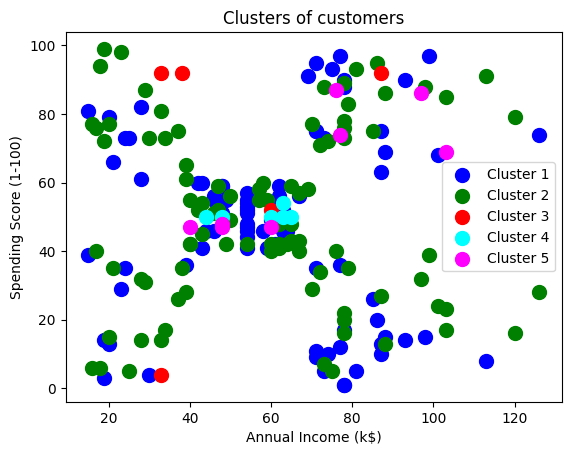

In [23]:
X = df1.iloc[:, [2,3]].values
plt.scatter(X[y_kmo == 0, 0], X[y_kmo == 0, 1], s = 100, c = 'blue', label = 'Cluster 1') #for first cluster  
plt.scatter(X[y_kmo == 1, 0], X[y_kmo == 1, 1], s = 100, c = 'green', label = 'Cluster 2') #for second cluster  
plt.scatter(X[y_kmo== 2, 0], X[y_kmo == 2, 1], s = 100, c = 'red', label = 'Cluster 3') #for third cluster  
plt.scatter(X[y_kmo == 3, 0], X[y_kmo == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4') #for fourth cluster  
plt.scatter(X[y_kmo == 4, 0], X[y_kmo == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5') #for fifth cluster    
plt.title('Clusters of customers')  
plt.xlabel('Annual Income (k$)')  
plt.ylabel('Spending Score (1-100)')  
plt.legend()  
plt.show()  

In [99]:
import plotly as py
import plotly.graph_objs as go
#Create a 3d plot to view the data sepparation made by Kmodes
trace1 = go.Scatter3d(
    x= df1['Spending Score (1-100)'],
    y= df1['Annual Income (k$)'],
    z= df1['Age'],
    mode='markers',
     marker=dict(
        color = y_kmo, 
        size= 10,
        line=dict(
            color= y_kmo,
        ),
        opacity = 0.9
     )
)
layout = go.Layout(
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Spending Score'),
            yaxis = dict(title  = 'Annual_income'),
            zaxis = dict(title  = 'Age')
        )
)
fig = go.Figure(data=trace1, layout=layout)
py.offline.iplot(fig)

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, predicted_labels)
print()

-0.34196132185849365

In [25]:
from sklearn.metrics import calinski_harabasz_score
calinski_harabasz_score(X, predicted_labels)

0.877363259914544

In [26]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(X, predicted_labels)

14.72649820473688